# CeBr3 (CH1)

In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
from datetime import date

---

# Load data and get time

### background

#### 17/12

In [2]:
bg = {}

energy1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Energy_ch1.txt", skiprows=1)
timestamps1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Timestamp_ch1.txt", skiprows=1)

channels1 = energy1[:, 0]
counts1 = energy1[:, 1]
t1 = timestamps1[:, 0]
time1 = (t1[-1] - t1[0]) * 1e-12

bg["d"] = {
    "channels": channels1,
    "counts": counts1,
    "time": time1
}

#### 18/03

In [3]:
energy2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Energy_ch1.txt", skiprows=1)
timestamps2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Timestamp_ch1.txt", skiprows=1)

channels2 = energy2[:, 0]
counts2 = energy2[:, 1]
t2 = timestamps2[:, 0]
time2 = (t2[-1] - t2[0]) * 1e-12

bg["m"] = {
    "channels": channels2,
    "counts": counts2,
    "time": time2
}

### Na22

#### 17/12

In [4]:
na22d = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 Na22 pos{}"

for i in range(1, 10):
    path = base_path.format(i)
    
    energy = np.loadtxt(f"{path}\\Energy_ch1.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch1.txt", skiprows=1)
    
    channels = energy[:, 0]
    counts = energy[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22d[f"{i}"] = {
        "channels": channels,
        "counts": counts,
        "time": time
    }

#### 18/03

In [5]:
na22m = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_Na22Pos{}"

for i in range(1, 21):
    path = base_path.format(i)
    
    energy = np.loadtxt(f"{path}\\Energy_ch1.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch1.txt", skiprows=1)
    
    channels = energy[:, 0]
    counts = energy[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22m[f"{i}"] = {
        "channels": channels,
        "counts": counts,
        "time": time
    }

---

# Subtract background

### background

#### 17/12

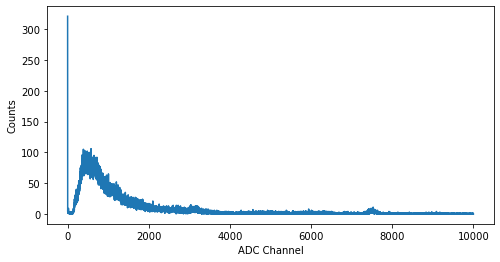

In [6]:
#spectrum background
range_bg = (bg["d"]["channels"] > 0) & (bg["d"]["channels"] < 10000)
plt.figure(figsize=(8, 4))
plt.plot(bg["d"]["channels"][range_bg], bg["d"]["counts"][range_bg])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

#### 18/03

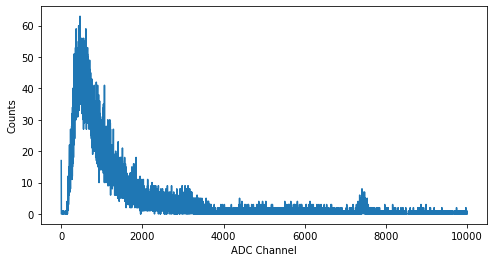

In [7]:
#spectrum background
range_bg = (bg["m"]["channels"] > 0) & (bg["m"]["channels"] < 10000)

plt.figure(figsize=(8, 4))
plt.plot(bg["m"]["channels"][range_bg], bg["m"]["counts"][range_bg])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

### Na22

#### 17/12

In [8]:
for key in na22d:
    counts_bg_na22 = bg["d"]["counts"] * (na22d[key]["time"] / bg["d"]["time"])
    na22d[key]["netcounts"] = na22d[key]["counts"] - counts_bg_na22
    na22d[key]["netcounts"][na22d[key]["netcounts"] < 0] = 0

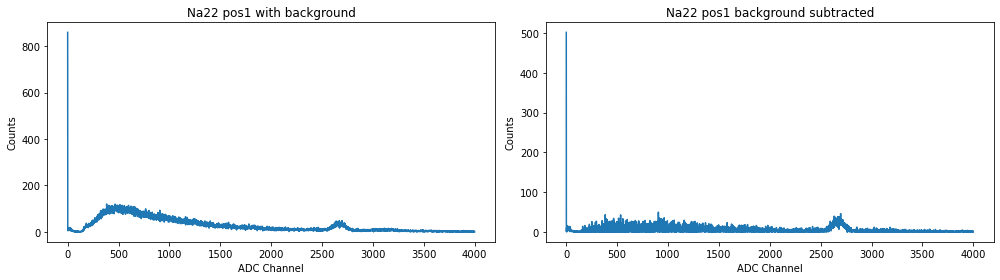

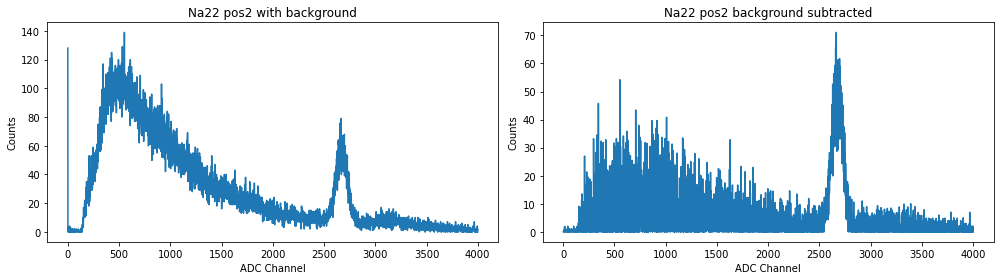

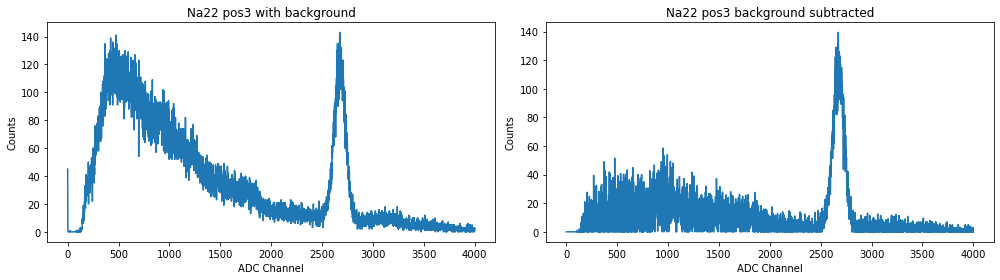

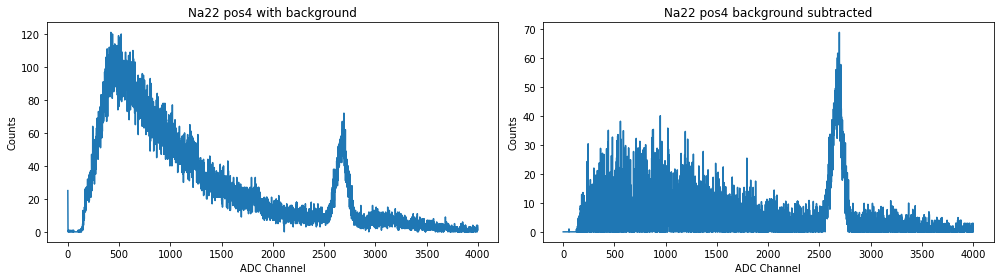

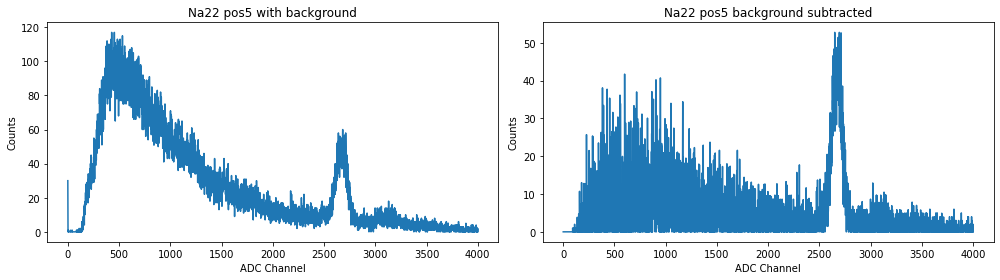

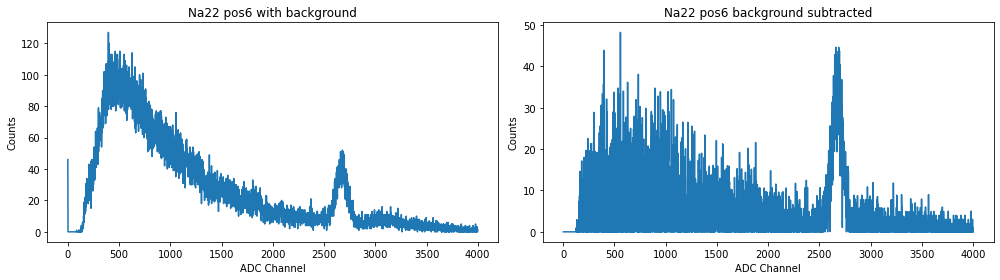

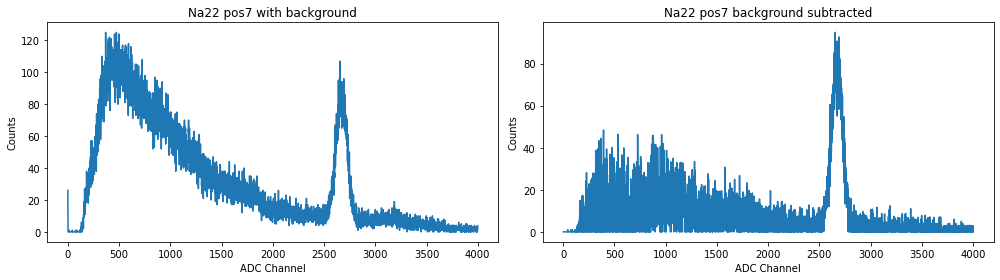

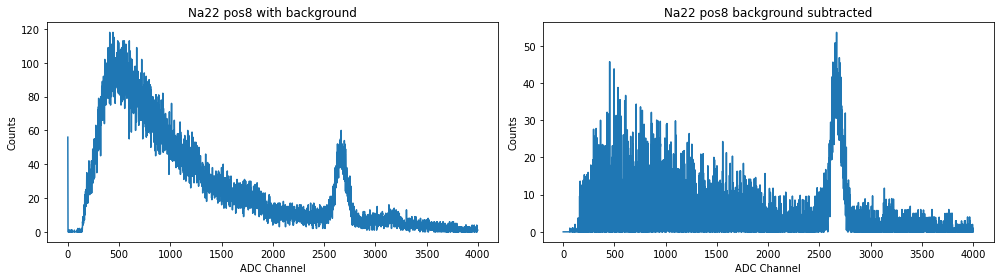

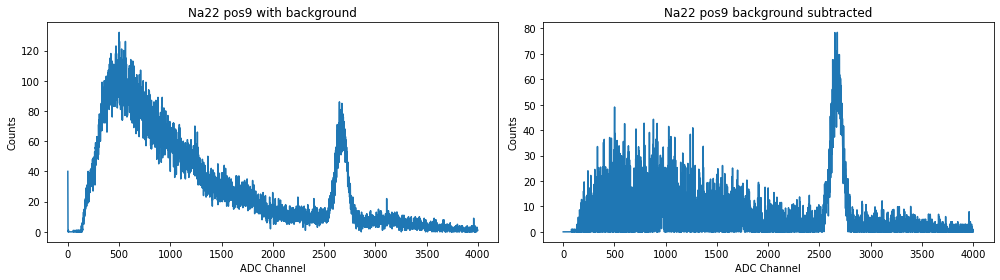

In [9]:
for key in na22d:
    range_na22 = (na22d[key]["channels"] > 0) & (na22d[key]["channels"] < 4000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22d[key]["channels"][range_na22], na22d[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("ADC Channel")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22d[key]["channels"][range_na22], na22d[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("ADC Channel")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

#### 18/03

In [10]:
for key in na22m:
    counts_bg_na22 = bg["m"]["counts"] * (na22m[key]["time"] / bg["m"]["time"])
    na22m[key]["netcounts"] = na22m[key]["counts"] - counts_bg_na22
    na22m[key]["netcounts"][na22m[key]["netcounts"] < 0] = 0

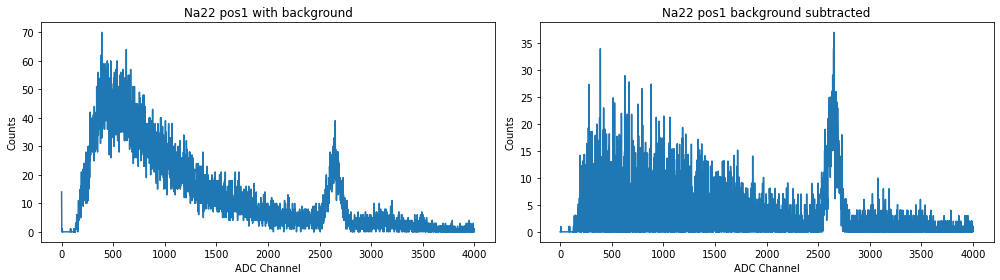

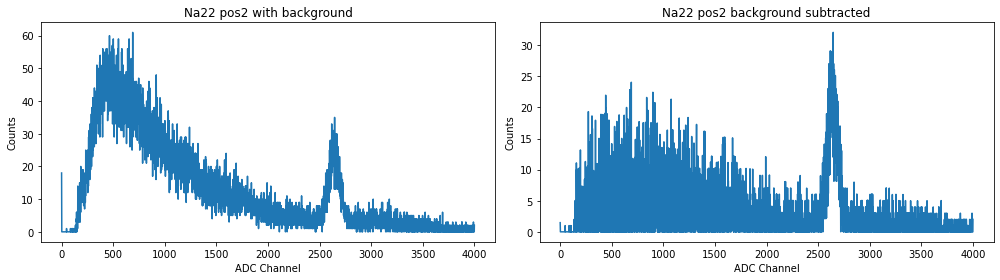

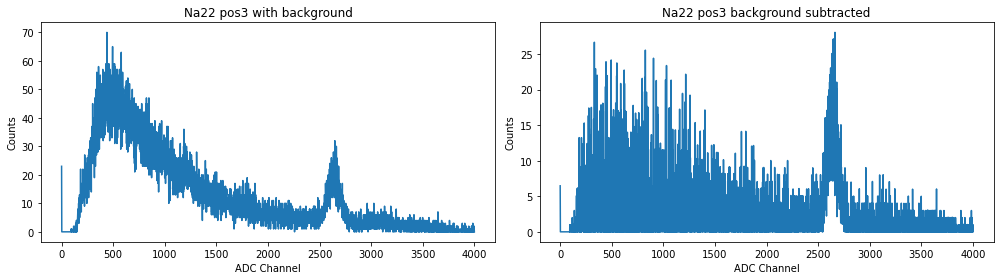

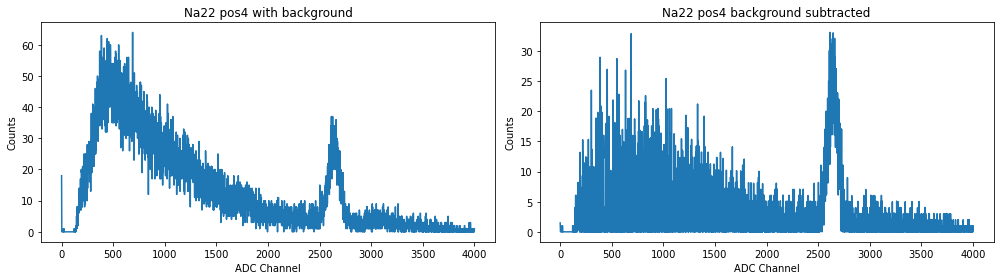

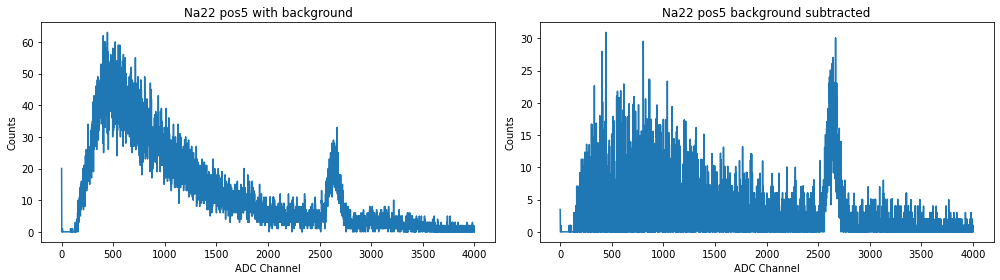

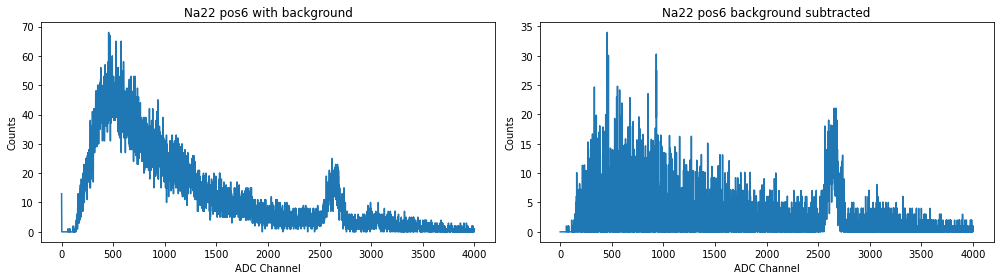

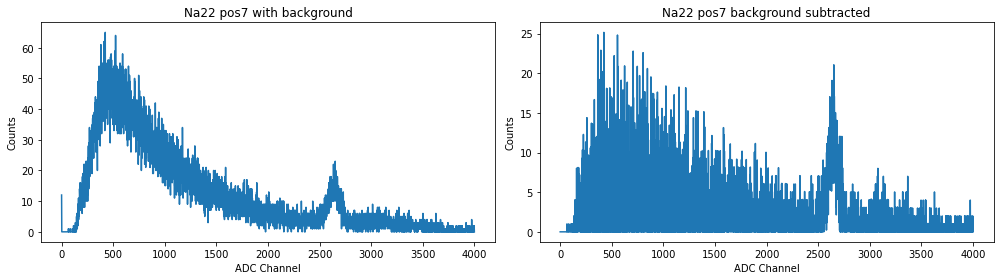

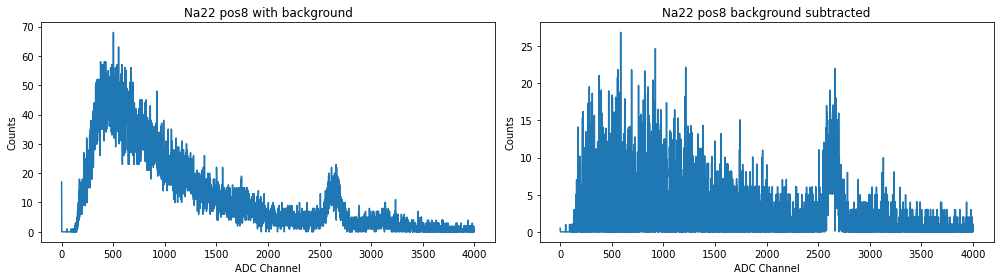

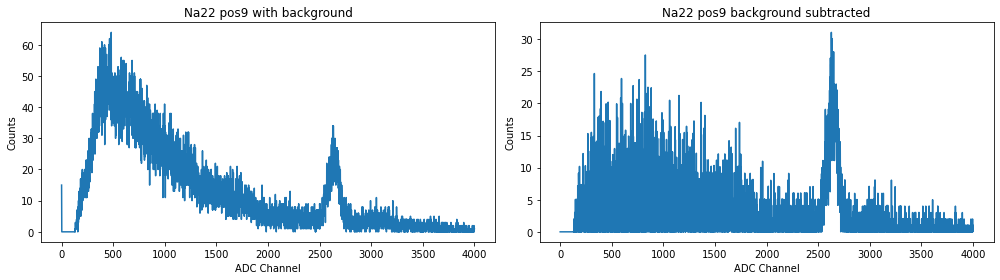

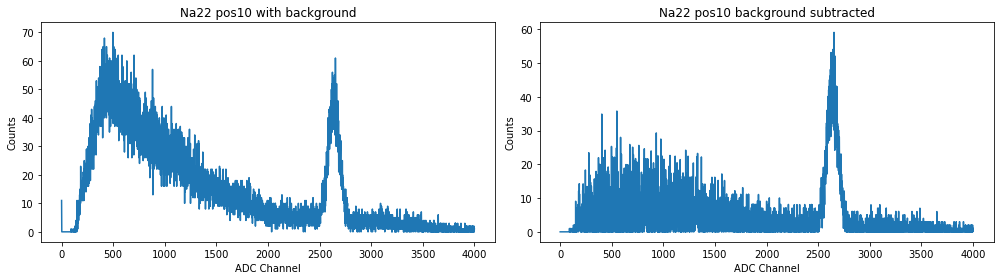

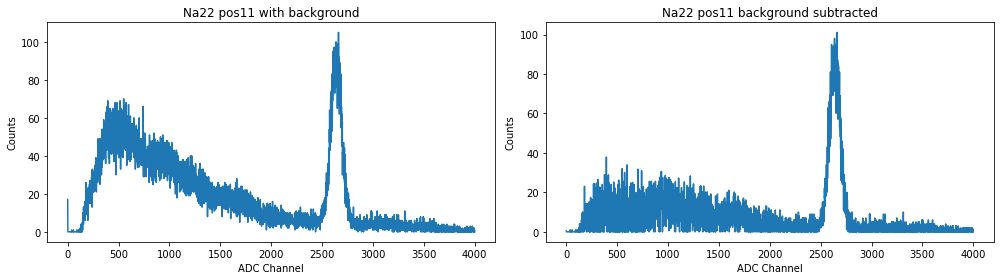

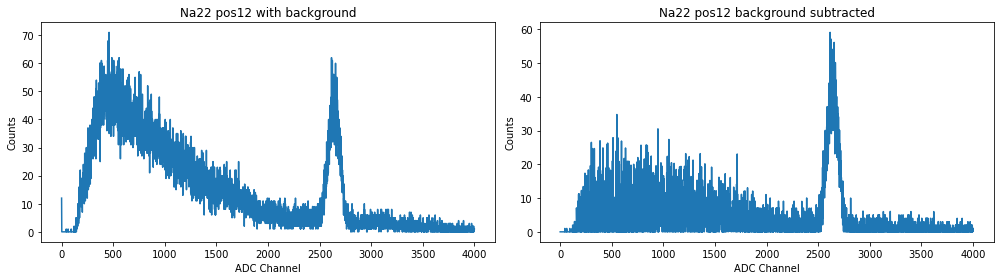

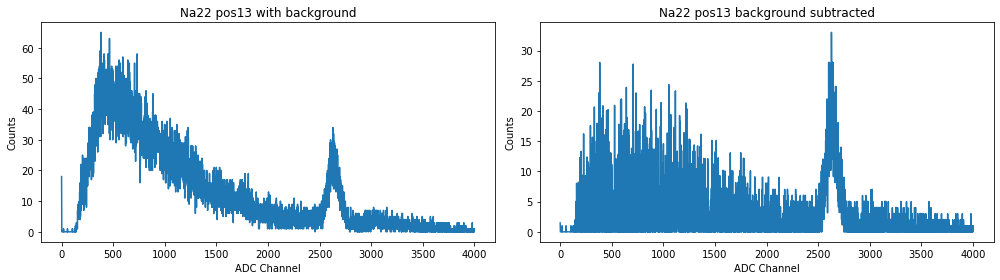

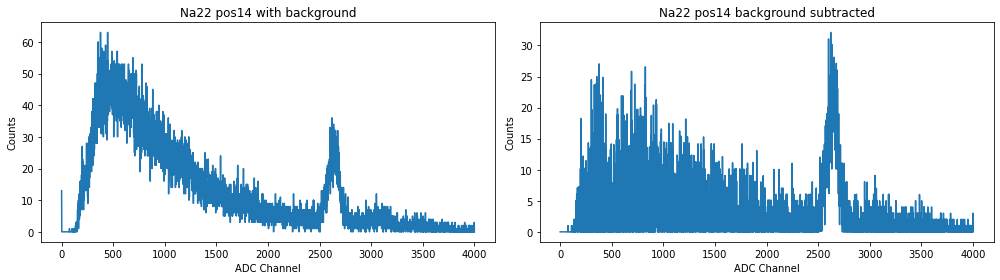

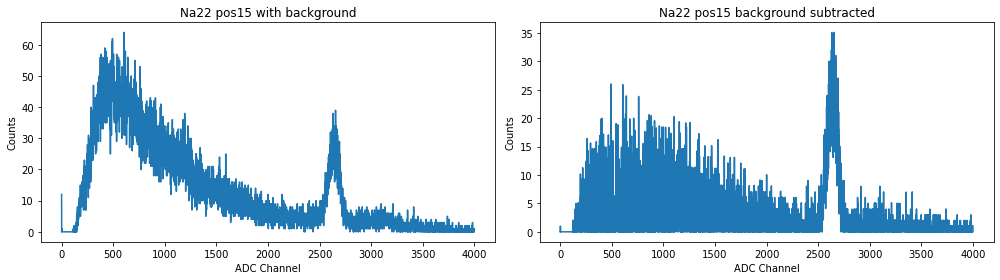

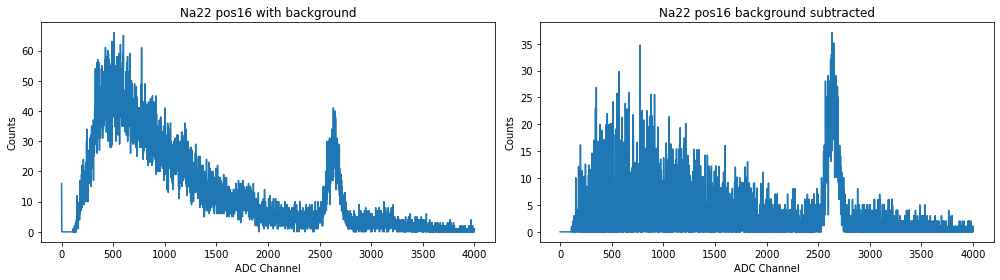

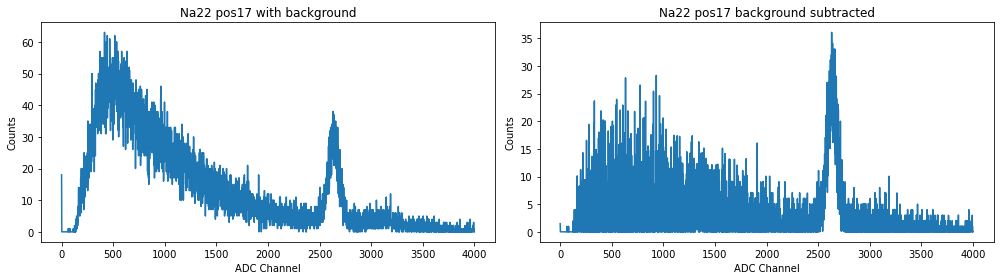

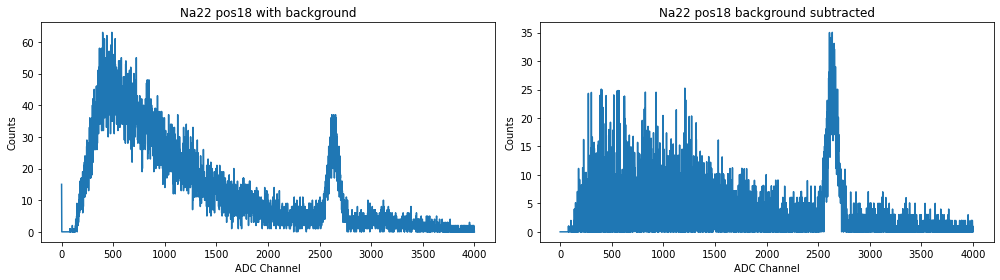

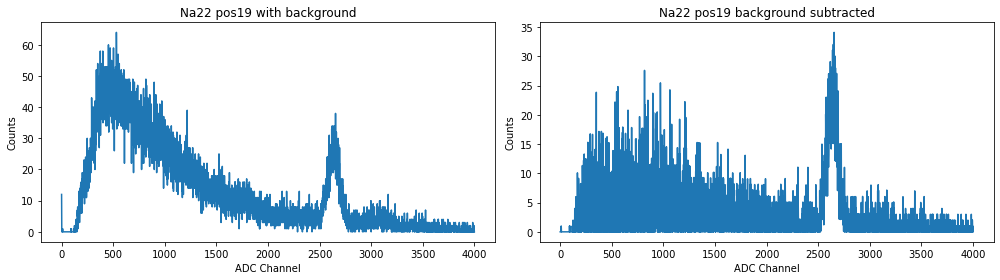

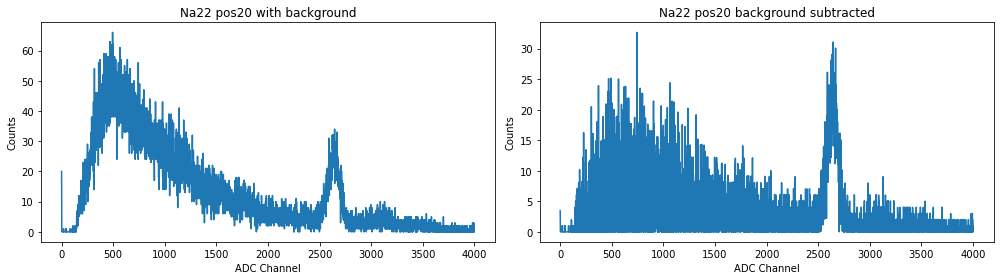

In [11]:
for key in na22m:
    range_na22 = (na22m[key]["channels"] > 0) & (na22m[key]["channels"] < 4000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22m[key]["channels"][range_na22], na22m[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("ADC Channel")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22m[key]["channels"][range_na22], na22m[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("ADC Channel")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    display(plt.gcf())  
    plt.close()

---

# Statistical errors

#### 17/12

In [12]:
for key in na22d:
    na22d[key]["sigma_counts"] = np.sqrt(na22d[key]["counts"] + (na22d[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22d[key]["sigma_counts"][na22d[key]["sigma_counts"] == 0] = 1

#### 18/03

In [13]:
for key in na22m:
    na22m[key]["sigma_counts"] = np.sqrt(na22m[key]["counts"] + (na22m[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22m[key]["sigma_counts"][na22m[key]["sigma_counts"] == 0] = 1

---

# Peak information

In [14]:
activity = 36200
halflife = 2.6
d0 = date(2010, 6, 1)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

542.5358499132185


In [15]:
energy_na22 = 511
channel_na22 = 2650
intensity_na22 = 179.8
activity_na22 = 542.5358499132185

---

# Fit peaks

In [16]:
def model(x, A, mu, sigma, B, c):
    return (A / (np.sqrt(2*np.pi)*sigma)) * np.exp(-(x-mu)**2/(2*sigma**2)) + B*x + c

#### 17/12

Counts (A): 3531.62 ± 149.30
Mean (mu): 2672.96 ± 1.82
Sigma: 55.17 ± 2.05
Background linear (B): -0.0027 ± 0.0019
Background constant (c): 8.84 ± 5.04

Reduced chi²: 0.8437148149
P-value: 0.989231614822287


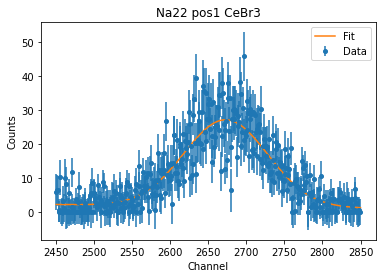

Counts (A): 6503.03 ± 162.85
Mean (mu): 2673.85 ± 1.12
Sigma: 54.34 ± 1.22
Background linear (B): -0.0024 ± 0.0020
Background constant (c): 8.30 ± 5.32

Reduced chi²: 0.8455660735
P-value: 0.988375089723652


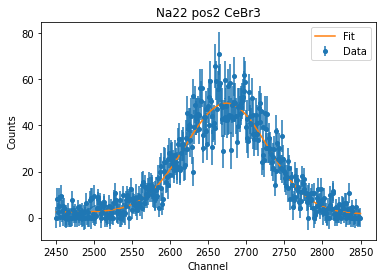

Counts (A): 15220.29 ± 208.43
Mean (mu): 2675.02 ± 0.65
Sigma: 55.08 ± 0.69
Background linear (B): -0.0071 ± 0.0024
Background constant (c): 21.84 ± 6.11

Reduced chi²: 0.9133379729
P-value: 0.890853446543482


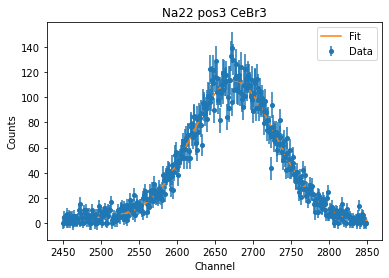

Counts (A): 5508.22 ± 146.91
Mean (mu): 2675.60 ± 1.16
Sigma: 51.76 ± 1.27
Background linear (B): -0.0049 ± 0.0019
Background constant (c): 15.40 ± 5.05

Reduced chi²: 0.8062578725
P-value: 0.998119086129902


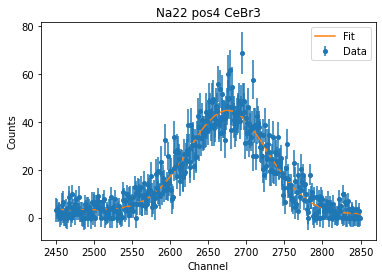

Counts (A): 5213.02 ± 141.02
Mean (mu): 2670.84 ± 1.20
Sigma: 51.55 ± 1.27
Background linear (B): -0.0049 ± 0.0018
Background constant (c): 14.96 ± 4.85

Reduced chi²: 0.8923427173
P-value: 0.939068100194735


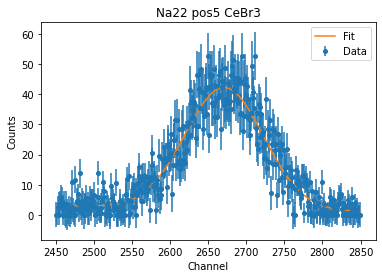

Counts (A): 4099.85 ± 139.69
Mean (mu): 2673.13 ± 1.48
Sigma: 53.08 ± 1.63
Background linear (B): -0.0031 ± 0.0018
Background constant (c): 9.85 ± 4.81

Reduced chi²: 0.7867628297
P-value: 0.999351728938555


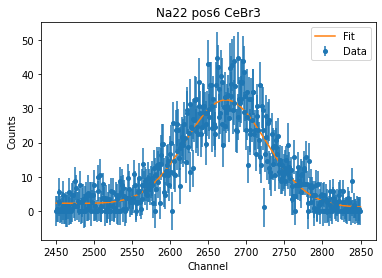

Counts (A): 10293.26 ± 177.23
Mean (mu): 2672.25 ± 0.81
Sigma: 54.28 ± 0.85
Background linear (B): -0.0066 ± 0.0021
Background constant (c): 19.93 ± 5.41

Reduced chi²: 0.8948664001
P-value: 0.934320062978595


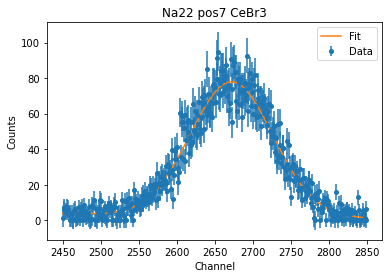

Counts (A): 4687.89 ± 140.12
Mean (mu): 2670.24 ± 1.31
Sigma: 51.82 ± 1.41
Background linear (B): -0.0038 ± 0.0019
Background constant (c): 12.49 ± 4.90

Reduced chi²: 0.8620457907
P-value: 0.977880767390311


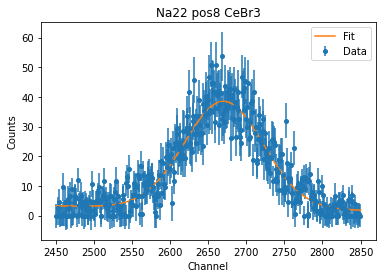

Counts (A): 7856.79 ± 159.94
Mean (mu): 2671.30 ± 0.93
Sigma: 52.85 ± 0.99
Background linear (B): -0.0058 ± 0.0020
Background constant (c): 17.71 ± 5.15

Reduced chi²: 0.8597866508
P-value: 0.979667199738769


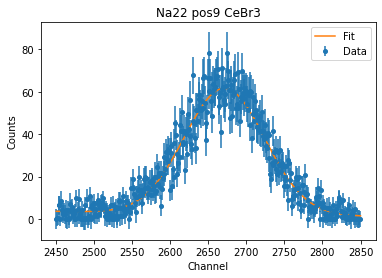

[3531.6163970778507, 6503.033800252215, 15220.286569064896, 5508.223284818891, 5213.019812418947, 4099.848519289972, 10293.256797897093, 4687.888173170325, 7856.790372167435]


In [17]:
counts_listd = []
countserr_listd = []
mu_listd = []
muerr_listd = []
sigma_listd = []
sigmaerr_listd = []

for key in na22d:
    peak_channel_guess = channel_na22
    fit_width = 200
    
    xmin = peak_channel_guess - fit_width
    xmax = peak_channel_guess + fit_width
    
    mask = (na22d[key]["channels"] >= xmin) & (na22d[key]["channels"] <= xmax)
    x = na22d[key]["channels"][mask]
    y = na22d[key]["netcounts"][mask]
    
    A_guess = np.sum(y)
    mu_guess = peak_channel_guess
    sigma_guess = 10
    B_guess = 0
    c_guess = np.min(y)
    
    p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]
    
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=p0,
        sigma=na22d[key]["sigma_counts"][mask],
        absolute_sigma=True
    )
    
    perr = np.sqrt(np.diag(pcov))
    A, mu, sigma, B, c = popt
    A_err, mu_err, sigma_err, B_err, c_err = perr
    y_fit = model(x, *popt)
    
    chi2_val = np.sum(((y - y_fit)/na22d[key]["sigma_counts"][mask])**2)
    ndof = len(x) - len(popt)
    chi2_red = chi2_val / ndof
    p_value = 1 - chi2.cdf(chi2_val, ndof)
    
    print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
    print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
    print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")
    print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
    print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")
    print()
    print(f"Reduced chi²: {chi2_red:.10f}")
    print(f"P-value: {p_value:.15f}")
    
    counts_listd.append(A)
    countserr_listd.append(A_err)
    mu_listd.append(mu)
    muerr_listd.append(mu_err)
    sigma_listd.append(sigma)
    sigmaerr_listd.append(sigma_err)
    
    x_plot = np.linspace(xmin, xmax, 1000)
    plt.errorbar(x, y, yerr=na22d[key]["sigma_counts"][mask], fmt='o', label="Data", markersize=4)
    plt.plot(x_plot, model(x_plot, *popt), label="Fit")
    plt.xlabel("Channel")
    plt.ylabel("Counts")
    plt.title(f"Na22 pos{key} CeBr3")
    plt.legend()
    plt.show()


print(counts_listd)

In [18]:
print(len(counts_listd))

9


#### 18/03

Counts (A): 2567.02 ± 86.07
Mean (mu): 2644.75 ± 1.57
Sigma: 51.70 ± 1.62
Background linear (B): -0.0003 ± 0.0010
Background constant (c): 1.50 ± 2.76

Reduced chi²: 0.8437462810
P-value: 0.989217518039996


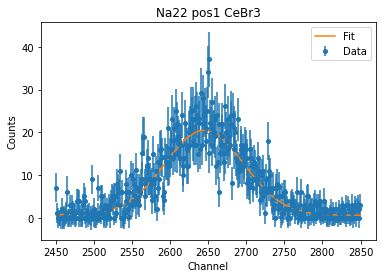

Counts (A): 2484.94 ± 83.25
Mean (mu): 2641.98 ± 1.53
Sigma: 49.61 ± 1.55
Background linear (B): 0.0006 ± 0.0010
Background constant (c): -0.73 ± 2.76

Reduced chi²: 0.9203392762
P-value: 0.870089882259775


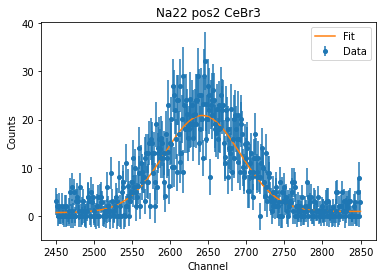

Counts (A): 1992.20 ± 87.18
Mean (mu): 2638.68 ± 2.00
Sigma: 53.35 ± 2.14
Background linear (B): -0.0010 ± 0.0011
Background constant (c): 3.50 ± 2.95

Reduced chi²: 0.8583767535
P-value: 0.980720383684202


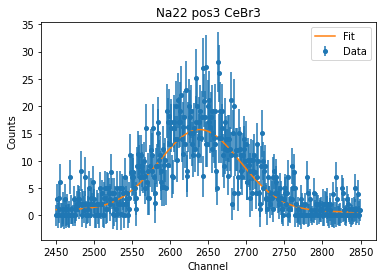

Counts (A): 3009.06 ± 89.11
Mean (mu): 2640.78 ± 1.40
Sigma: 51.44 ± 1.42
Background linear (B): -0.0006 ± 0.0010
Background constant (c): 2.34 ± 2.80

Reduced chi²: 0.8914928077
P-value: 0.940607202595992


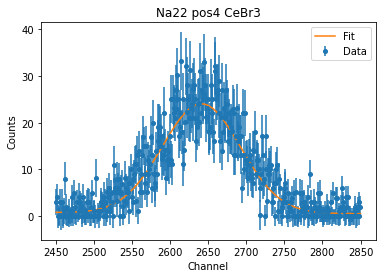

Counts (A): 2019.39 ± 77.18
Mean (mu): 2639.06 ± 1.69
Sigma: 48.16 ± 1.71
Background linear (B): -0.0002 ± 0.0010
Background constant (c): 1.27 ± 2.73

Reduced chi²: 0.8893503207
P-value: 0.944355985942180


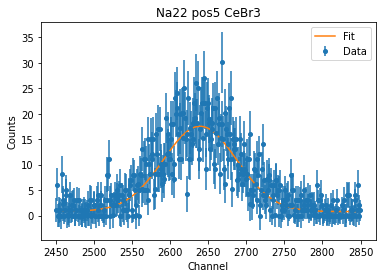

Counts (A): 1521.02 ± 77.95
Mean (mu): 2637.39 ± 2.30
Sigma: 51.62 ± 2.41
Background linear (B): -0.0011 ± 0.0010
Background constant (c): 3.51 ± 2.75

Reduced chi²: 0.7621282691
P-value: 0.999857175018449


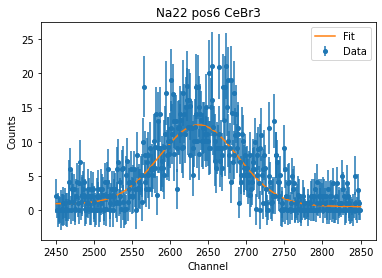

Counts (A): 1245.08 ± 70.57
Mean (mu): 2638.75 ± 2.43
Sigma: 48.26 ± 2.55
Background linear (B): 0.0001 ± 0.0010
Background constant (c): 0.53 ± 2.68

Reduced chi²: 0.8021084238
P-value: 0.998486513076682


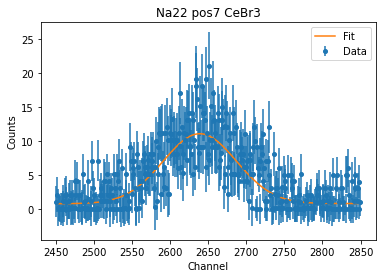

Counts (A): 1302.66 ± 78.26
Mean (mu): 2638.72 ± 2.68
Sigma: 52.32 ± 2.82
Background linear (B): -0.0019 ± 0.0010
Background constant (c): 5.59 ± 2.83

Reduced chi²: 0.8196211554
P-value: 0.996336852909934


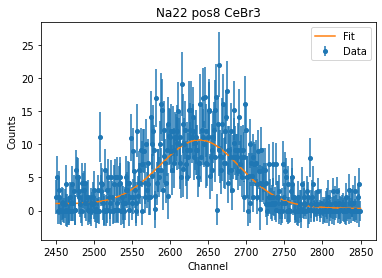

Counts (A): 2312.42 ± 79.84
Mean (mu): 2637.12 ± 1.56
Sigma: 49.01 ± 1.57
Background linear (B): -0.0006 ± 0.0010
Background constant (c): 2.36 ± 2.70

Reduced chi²: 0.8164017363
P-value: 0.996865939349002


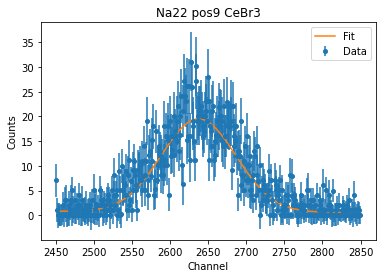

Counts (A): 5464.32 ± 109.07
Mean (mu): 2638.20 ± 0.98
Sigma: 53.11 ± 0.98
Background linear (B): -0.0012 ± 0.0012
Background constant (c): 4.06 ± 3.14

Reduced chi²: 0.9027263448
P-value: 0.917756294409556


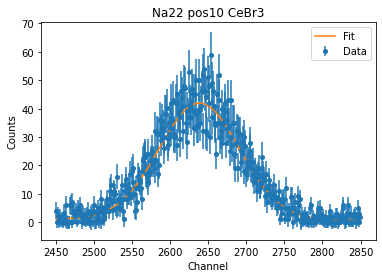

Counts (A): 11252.78 ± 139.39
Mean (mu): 2640.46 ± 0.63
Sigma: 52.92 ± 0.60
Background linear (B): -0.0017 ± 0.0013
Background constant (c): 5.93 ± 3.52

Reduced chi²: 1.0639078343
P-value: 0.183189881402069


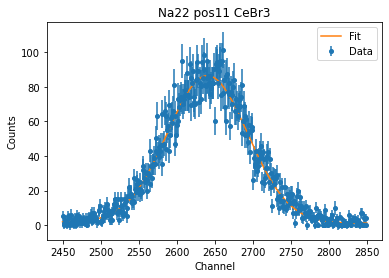

Counts (A): 5460.59 ± 106.85
Mean (mu): 2640.36 ± 0.95
Sigma: 51.64 ± 0.94
Background linear (B): -0.0017 ± 0.0011
Background constant (c): 5.64 ± 3.09

Reduced chi²: 1.0255059928
P-value: 0.352300659021668


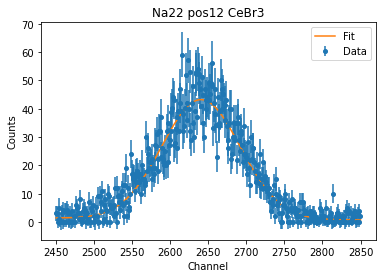

Counts (A): 2416.04 ± 86.45
Mean (mu): 2637.23 ± 1.67
Sigma: 52.44 ± 1.73
Background linear (B): -0.0004 ± 0.0010
Background constant (c): 1.80 ± 2.82

Reduced chi²: 0.8389267950
P-value: 0.991201615809836


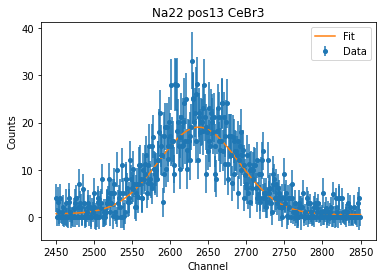

Counts (A): 2670.20 ± 86.67
Mean (mu): 2636.57 ± 1.52
Sigma: 51.63 ± 1.56
Background linear (B): -0.0001 ± 0.0010
Background constant (c): 0.86 ± 2.79

Reduced chi²: 0.8639706654
P-value: 0.976258552192486


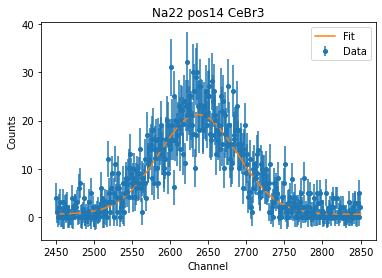

Counts (A): 2867.75 ± 86.74
Mean (mu): 2636.63 ± 1.38
Sigma: 49.80 ± 1.39
Background linear (B): -0.0014 ± 0.0011
Background constant (c): 4.49 ± 2.88

Reduced chi²: 0.8323366172
P-value: 0.993402602019124


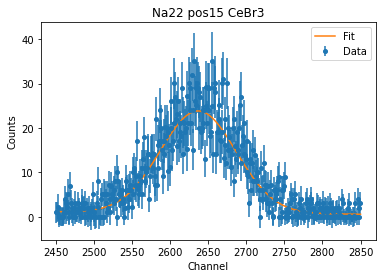

Counts (A): 2973.20 ± 93.29
Mean (mu): 2638.49 ± 1.47
Sigma: 52.97 ± 1.53
Background linear (B): -0.0014 ± 0.0011
Background constant (c): 4.39 ± 3.00

Reduced chi²: 0.9504881561
P-value: 0.752955332629898


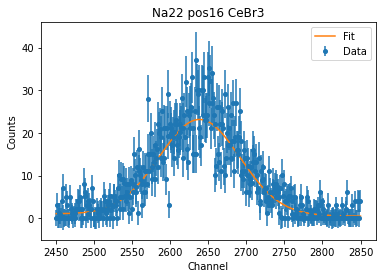

Counts (A): 2900.59 ± 87.04
Mean (mu): 2635.97 ± 1.36
Sigma: 49.22 ± 1.38
Background linear (B): -0.0014 ± 0.0011
Background constant (c): 4.53 ± 2.93

Reduced chi²: 0.9466958474
P-value: 0.770052395437899


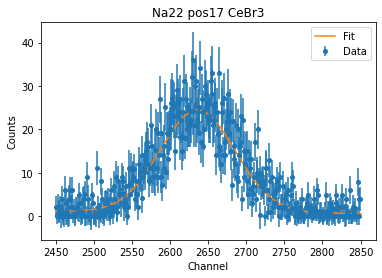

Counts (A): 3020.63 ± 90.42
Mean (mu): 2636.60 ± 1.41
Sigma: 52.11 ± 1.44
Background linear (B): -0.0002 ± 0.0010
Background constant (c): 1.06 ± 2.85

Reduced chi²: 0.8245562339
P-value: 0.995373089299685


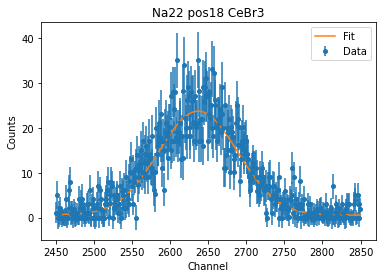

Counts (A): 2866.54 ± 90.16
Mean (mu): 2635.77 ± 1.46
Sigma: 51.72 ± 1.51
Background linear (B): -0.0006 ± 0.0011
Background constant (c): 2.30 ± 2.92

Reduced chi²: 0.8852094269
P-value: 0.951085450326798


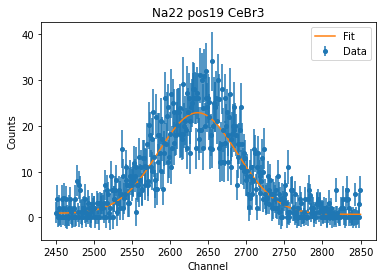

Counts (A): 2696.76 ± 86.72
Mean (mu): 2635.73 ± 1.51
Sigma: 51.69 ± 1.54
Background linear (B): -0.0011 ± 0.0010
Background constant (c): 3.51 ± 2.78

Reduced chi²: 0.8584371578
P-value: 0.980676208328281


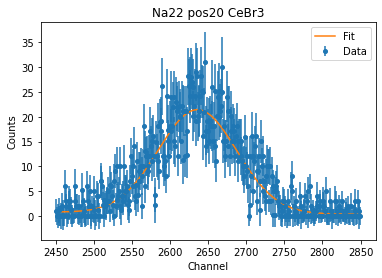

[2567.0209659479024, 2484.9429616440566, 1992.2024982435887, 3009.0639368860534, 2019.38947386106, 1521.0151149500405, 1245.083769599443, 1302.6597974289834, 2312.4219892853166, 5464.315213013424, 11252.783933130237, 5460.586783852362, 2416.042387119686, 2670.1961760985328, 2867.747447524697, 2973.1974106737885, 2900.5852616214415, 3020.63499895495, 2866.5416935735593, 2696.7642745591484]


In [19]:
counts_listm = []
countserr_listm = []
mu_listm = []
muerr_listm = []
sigma_listm = []
sigmaerr_listm = []

for key in na22m:
    peak_channel_guess = channel_na22
    fit_width = 200
    
    xmin = peak_channel_guess - fit_width
    xmax = peak_channel_guess + fit_width
    
    mask = (na22m[key]["channels"] >= xmin) & (na22m[key]["channels"] <= xmax)
    x = na22m[key]["channels"][mask]
    y = na22m[key]["netcounts"][mask]
    
    A_guess = np.sum(y)
    mu_guess = peak_channel_guess
    sigma_guess = 10
    B_guess = 0
    c_guess = np.min(y)
    
    p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]
    
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=p0,
        sigma=na22m[key]["sigma_counts"][mask],
        absolute_sigma=True
    )
    
    perr = np.sqrt(np.diag(pcov))
    A, mu, sigma, B, c = popt
    A_err, mu_err, sigma_err, B_err, c_err = perr
    y_fit = model(x, *popt)
    
    chi2_val = np.sum(((y - y_fit)/na22m[key]["sigma_counts"][mask])**2)
    ndof = len(x) - len(popt)
    chi2_red = chi2_val / ndof
    p_value = 1 - chi2.cdf(chi2_val, ndof)
    
    print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
    print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
    print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")
    print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
    print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")
    print()
    print(f"Reduced chi²: {chi2_red:.10f}")
    print(f"P-value: {p_value:.15f}")
    
    counts_listm.append(A)
    countserr_listm.append(A_err)
    mu_listm.append(mu)
    muerr_listm.append(mu_err)
    sigma_listm.append(sigma)
    sigmaerr_listm.append(sigma_err)
    
    x_plot = np.linspace(xmin, xmax, 1000)
    plt.errorbar(x, y, yerr=na22m[key]["sigma_counts"][mask], fmt='o', label="Data", markersize=4)
    plt.plot(x_plot, model(x_plot, *popt), label="Fit")
    plt.xlabel("Channel")
    plt.ylabel("Counts")
    plt.title(f"Na22 pos{key} CeBr3")
    plt.legend()
    plt.show()

print(counts_listm)

In [20]:
print(len(counts_listm))

20


---

# Absolute efficiency

#### 17/12

##### translational measurements (middle x-axis)
1. (4,1): 4.2cm from LaBr3(Ce), 10.2cm from CeBr3 
2. (4,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3
3. (4,7): 10.2cm from LaBr3(Ce), 4.2cm from CeBr3
4. (1,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
5. (7,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
6. (4,2): 5.2cm from LaBr3(Ce), 9.2cm from CeBr3 
7. (4,6): 9.2cm from LaBr3(Ce), 5.2cm from CeBr3 
8. (4,3): 6.2cm from LaBr3(Ce), 8.2cm from CeBr3 
9. (4,5): 8.2cm from LaBr3(Ce), 6.2cm from CeBr3 

In [21]:
translationalx = np.array([10.2, 7.2, 4.2, 7.8, 7.8, 9.2, 5.2, 8.2, 6.2])

In [22]:
times = np.array([na22d[key]["time"] for key in na22d])
absolute_effd = counts_listd/(activity_na22*times*(intensity_na22/100))

In [23]:
#error on efficiency
rel_counts = np.array(countserr_listd) / np.array(counts_listd)
abs_eff_errd = absolute_effd * np.sqrt(rel_counts**2)

In [24]:
def inv_square_model(x, A, B, C):
    return A / (x + B)**2 + C

A = 7.3455e-01 ± 1.3549e-01
B = 1.5940e+00 ± 4.6436e-01
C = 1.3576e-04 ± 6.9988e-04


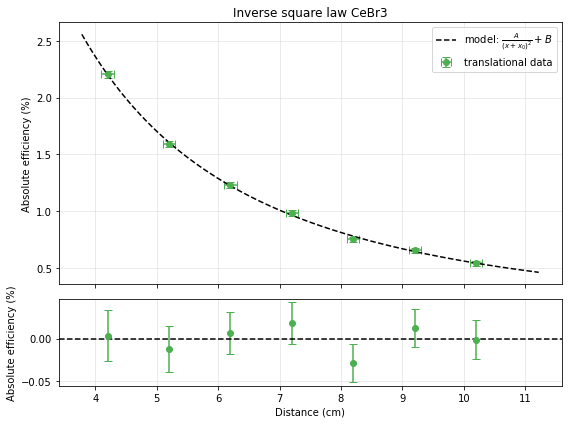

Reduced chi²: 0.658
P-value: 0.6836


In [25]:
# Fit the resolution
p0 = [1,0,0]
popt, pcov = curve_fit(
    inv_square_model,
    translationalx,
    absolute_effd,
    sigma=abs_eff_errd,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))
A_eff, B_eff, C_eff = popt

# Residuals
residuals = absolute_effd - inv_square_model(translationalx, *popt)

# --- Compute reduced chi² and p-value ---
chi2_val = np.sum((residuals / abs_eff_errd)**2)
ndof = len(translationalx) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

# --- Plotting ---
fig, (ax_main, ax_resid) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3,1]}, figsize=(8,6))

print(f"A = {A_eff:.4e} ± {perr[0]:.4e}")
print(f"B = {B_eff:.4e} ± {perr[1]:.4e}")
print(f"C = {C_eff:.4e} ± {perr[2]:.4e}")

# --- Main plot ---
E_plot = np.linspace(min(translationalx)*0.9, max(translationalx)*1.1, 500)

ax_main.errorbar(translationalx[[0,1,2,5,6,7,8]], absolute_effd[[0,1,2,5,6,7,8]]*100, xerr =0.1, yerr=abs_eff_errd[[0,1,2,5,6,7,8]]*100, fmt='o', color='#4CAF50', label='translational data', capsize=4)
ax_main.plot(E_plot, inv_square_model(E_plot, *popt)*100, 'k--', label=r'model: $\frac{A}{(x + x_0)^2} + B$')
ax_main.set_ylabel("Absolute efficiency (%)")
ax_main.set_title("Inverse square law CeBr3")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

ax_resid.errorbar(translationalx[[0,1,2,5,6,7,8]], residuals[[0,1,2,5,6,7,8]]*100, yerr=abs_eff_errd[[0,1,2,5,6,7,8]]*100, fmt='o', color='#4CAF50', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Distance (cm)")
ax_resid.set_ylabel("Absolute efficiency (%)")
ax_resid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

#### 18/03

- translational: 7 x 7 holes
- rotational: 45 degree rotations

1. (4,4)(not aligned yet)

##### turn casing
2. (4,4) 0° (casing line -> LaBr3(Ce))
3. (4,4) 90°
4. (4,4) 180°
5. (4,4) 270°

##### rotational measurements
6. (7,1) 0° (casing line -> CeBr3)
7. 45° (source closest to LaBr3(Ce))
8. 90°
9. 135° (source in middle (wall side))
10. 180°
11. 225° (source closest to CeBr3)
12. 270°
13. 315°

##### translational measurements (middle y-axis)
14. (7,4)(bottom middle hole)(casing line -> CeBr3)
15. (6,4)
16. (5,4)
17. (4,4)(middle hole)
18. (3,4)
19. (2,4)
20. (1,4)

In [26]:
translationaly = np.array([-3,-2,-1,0,1,2,3]) #14,15,16,17,18,19,20
rotational = np.array([0,45,90,135,180,225,270,315]) #6,7,8,9,10,11,12,13
casing = np.array([180,270,0,90]) #2,3,4,5

In [27]:
times = np.array([na22m[key]["time"] for key in na22m])
absolute_effm = counts_listm/(activity_na22*times*(intensity_na22/100))

In [28]:
#error on efficiency
rel_counts = np.array(countserr_listm) / np.array(counts_listm)
abs_eff_errm = absolute_effm * np.sqrt(rel_counts**2)

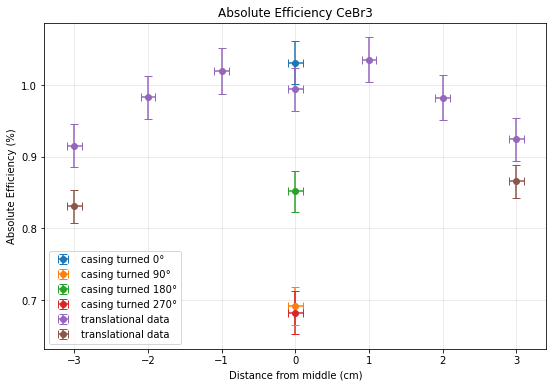

In [29]:
fig = plt.figure(figsize=(9,6))
plt.errorbar([0], absolute_effm[3]*100, xerr=0.1, yerr=abs_eff_errm[3]*100, fmt='o', label='casing turned 0°', capsize=4)
plt.errorbar([0], absolute_effm[4]*100, xerr=0.1, yerr=abs_eff_errm[4]*100, fmt='o', label='casing turned 90°', capsize=4)
plt.errorbar([0], absolute_effm[1]*100, xerr=0.1, yerr=abs_eff_errm[1]*100, fmt='o', label='casing turned 180°', capsize=4)
plt.errorbar([0], absolute_effm[2]*100, xerr=0.1, yerr=abs_eff_errm[2]*100, fmt='o', label='casing turned 270°', capsize=4)
plt.errorbar(translationaly, absolute_effm[13:20]*100, xerr=0.1, yerr=abs_eff_errm[13:20]*100, fmt='o', label='translational data', capsize=4)
plt.errorbar([3,-3], absolute_effd[3:5]*100, xerr=0.1, yerr=abs_eff_errd[3:5]*100, fmt='o', label='translational data', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Absolute Efficiency (%)")
plt.title("Absolute Efficiency CeBr3")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

- x = distance between source and middle circle (7.2 cm)
- r = distance from source to middle circle (radius)(3 cm)
$d(\theta) = \sqrt{x^2+r^2-2xr\cos(\theta - 225°)}$

In [30]:
def inv_square_model_degrees(x, A, B, C):
    d = np.sqrt(7.2**2 + 3**2 - 2*7.2*3*np.cos(np.radians(x-225)))
    return A / (d + B)**2 + C

A = 3.5690e-01 ± 3.0478e-02
B = -1.1612e+00 ± 1.2629e-01
C = -1.2898e-04 ± 3.6225e-04


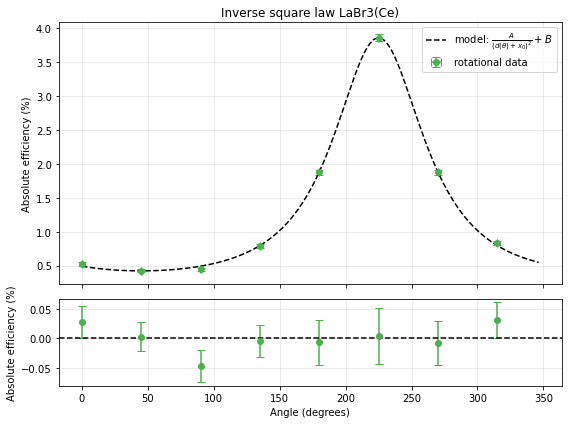

Reduced chi²: 1.074
P-value: 0.3727


In [31]:
# Fit the resolution
p0 = [1,0,0]
popt, pcov = curve_fit(
    inv_square_model_degrees,
    rotational,
    absolute_effm[5:13],
    sigma=abs_eff_errm[5:13],
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))
A_eff, B_eff, C_eff = popt

# Residuals
residuals = absolute_effm[5:13] - inv_square_model_degrees(rotational, *popt)

# --- Compute reduced chi² and p-value ---
chi2_val = np.sum((residuals / abs_eff_errm[5:13])**2)
ndof = len(rotational) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

# --- Plotting ---
fig, (ax_main, ax_resid) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3,1]}, figsize=(8,6))

print(f"A = {A_eff:.4e} ± {perr[0]:.4e}")
print(f"B = {B_eff:.4e} ± {perr[1]:.4e}")
print(f"C = {C_eff:.4e} ± {perr[2]:.4e}")

# --- Main plot ---
E_plot = np.linspace(min(rotational)*0.9, max(rotational)*1.1, 500)

ax_main.errorbar(rotational, absolute_effm[5:13]*100, xerr =0.1, yerr=abs_eff_errm[5:13]*100, fmt='o', color='#4CAF50', label='rotational data', capsize=4)
ax_main.plot(E_plot, inv_square_model_degrees(E_plot, *popt)*100, 'k--', label=r'model: $\frac{A}{(d(\theta) + x_0)^2} + B$')
ax_main.set_ylabel("Absolute efficiency (%)")
ax_main.set_title("Inverse square law LaBr3(Ce)")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

ax_resid.errorbar(rotational, residuals*100, yerr=abs_eff_errm[5:13]*100, fmt='o', color='#4CAF50', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Angle (degrees)")
ax_resid.set_ylabel("Absolute efficiency (%)")
ax_resid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")